In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from onb_analysis import *

In [2]:
df = pd.read_csv("20250713_df_vecs_only407.csv")
df = fname_to_dt(df)
df["timeitv"] = (df["DateTime"].dt.hour+1)//2*2
df.head()

,p_x,p_z,p_y,basal_vec_x,basal_vec_z,basal_vec_y,pca1_x,pca1_z,pca1_y,pca2_x,...,pca3_y2,pca3_z2,DateTime,plant label,lamina no.,TimeDelta,TimeDelta(min),Duration,Duration(min),timeitv
0,0.240956,0.959130,0.148360,0.800258,0.556342,0.223767,0.955850,0.271303,-0.112898,0.271597,...,0.713112,0.692015,2024-09-10 11:00:00,h,1,0 days,0.0,0 days,0.0,12
1,-0.366715,0.913762,0.174811,-0.829668,0.532499,0.167620,-0.917629,0.381998,0.109705,0.030685,...,0.326744,0.858034,2024-09-10 11:00:00,h,2,0 days,0.0,0 days,0.0,12
2,0.452207,0.876438,0.165425,0.786938,0.615762,0.039564,0.870520,0.491825,0.017398,0.058039,...,0.148419,0.859736,2024-09-10 11:00:00,h,3,0 days,0.0,0 days,0.0,12
3,0.248622,0.783854,0.568999,-0.457029,0.386146,0.801259,-0.455161,0.289940,0.841881,0.889432,...,-0.345426,0.937519,2024-09-10 11:00:00,h,4,0 days,0.0,0 days,0.0,12
4,-0.358477,0.880323,0.310686,-0.481135,0.385236,0.787466,-0.520955,0.233114,0.821135,-0.828253,...,-0.143814,0.967840,2024-09-10 11:00:00,h,5,0 days,0.0,0 days,0.0,12


In [3]:
df.shape

(407, 39)

In [4]:
type(df["DateTime"])

pandas.core.series.Series

In [5]:
len(df["plant label"].unique())

14

In [6]:
df.columns

Index(['p_x', 'p_z', 'p_y', 'basal_vec_x', 'basal_vec_z', 'basal_vec_y',
       'pca1_x', 'pca1_z', 'pca1_y', 'pca2_x', 'pca2_z', 'pca2_y', 'pca3_x',
       'pca3_z', 'pca3_y', 'cpl_x', 'cpl_z', 'cpl_y', 'ori_x', 'ori_z',
       'ori_y', 'file', 'pca1_x2', 'pca1_y2', 'pca1_z2', 'pca2_x2', 'pca2_y2',
       'pca2_z2', 'pca3_x2', 'pca3_y2', 'pca3_z2', 'DateTime', 'plant label',
       'lamina no.', 'TimeDelta', 'TimeDelta(min)', 'Duration',
       'Duration(min)', 'timeitv'],
      dtype='object')

In [7]:
pd_ele = df["pca1_z2"].apply(np.arcsin).apply(np.degrees)
df["PD.ele"] = pd_ele
pd_azi = np.arctan2(df["pca1_y2"],df["pca1_x2"]).apply(np.degrees)
df["PD.azi"] = pd_azi
ml_ele = df["pca2_z2"].apply(np.arcsin).apply(np.degrees)
df["ML.ele"] = ml_ele
ad_ele = df["pca3_z2"].apply(np.arcsin).apply(np.degrees)
df["AdAb.ele"] = ad_ele
ad_ele = df["p_z"].apply(np.arcsin).apply(np.degrees)
df["Pet.ele"] = ad_ele

In [8]:
df.head()

,p_x,p_z,p_y,basal_vec_x,basal_vec_z,basal_vec_y,pca1_x,pca1_z,pca1_y,pca2_x,...,TimeDelta,TimeDelta(min),Duration,Duration(min),timeitv,PD.ele,PD.azi,ML.ele,AdAb.ele,Pet.ele
0,0.240956,0.959130,0.148360,0.800258,0.556342,0.223767,0.955850,0.271303,-0.112898,0.271597,...,0 days,0.0,0 days,0.0,12,15.741842,-6.736148,-41.987002,43.789800,73.562620
1,-0.366715,0.913762,0.174811,-0.829668,0.532499,0.167620,-0.917629,0.381998,0.109705,0.030685,...,0 days,0.0,0 days,0.0,12,22.457501,173.182477,20.078093,59.096542,66.030548
2,0.452207,0.876438,0.165425,0.786938,0.615762,0.039564,0.870520,0.491825,0.017398,0.058039,...,0 days,0.0,0 days,0.0,12,29.460574,1.144932,-7.915032,59.286962,61.215602
3,0.248622,0.783854,0.568999,-0.457029,0.386146,0.801259,-0.455161,0.289940,0.841881,0.889432,...,0 days,0.0,0 days,0.0,12,16.854341,118.397783,-11.089238,69.638939,51.614800
4,-0.358477,0.880323,0.310686,-0.481135,0.385236,0.787466,-0.520955,0.233114,0.821135,-0.828253,...,0 days,0.0,0 days,0.0,12,13.480502,122.392396,5.426254,75.429879,61.681324


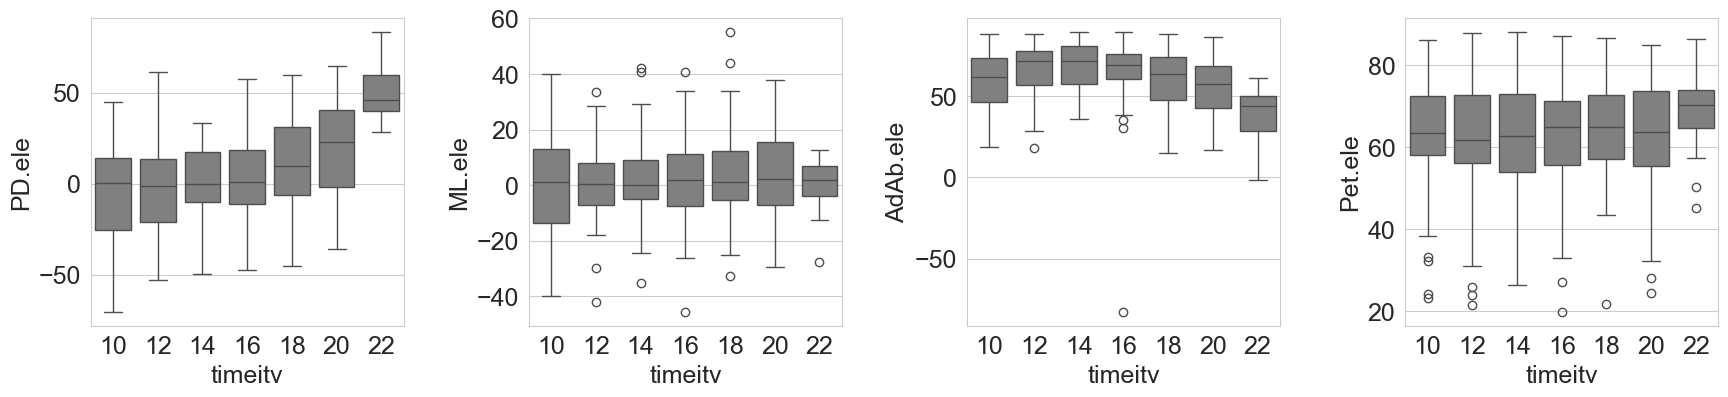

In [9]:
sns.set_style("whitegrid")
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 18

fig,axes = plt.subplots(
    figsize=(21,4),ncols=4,nrows=1
)
plt.subplots_adjust(wspace=0.4)

label_cols = df.filter(like=(".ele")).columns

for i in range(4):
    ax = axes[i]
    sns.boxplot(
        data=df,
        x="timeitv",
        y=label_cols[i],
        color="gray",
        ax=ax
    )
plt.show()

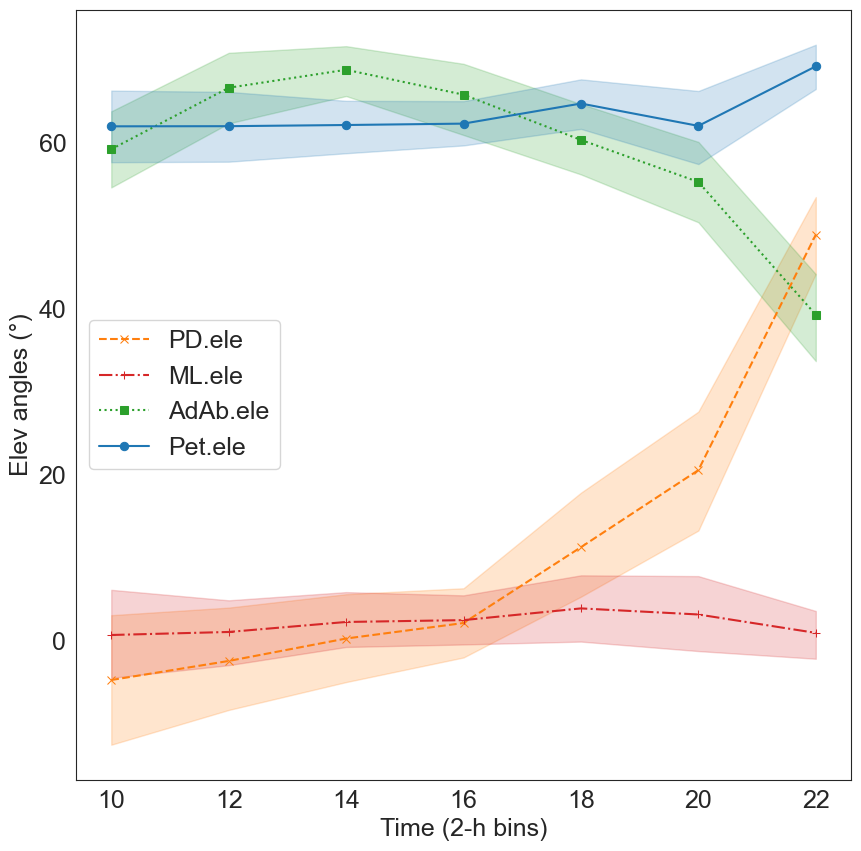

In [10]:
sns.set_style("white")
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 18

colors = ["tab:orange","tab:red","tab:green","tab:blue"]
markers = ["x","+","s","o"]
ls = ["--","-.",":","-"]

fig,ax = plt.subplots(
    figsize=(10,10)
)
plt.subplots_adjust(wspace=0.4)

label_cols = df.filter(like=(".ele")).columns

for i in range(4):
    sns.lineplot(
        data=df,
        x="timeitv",
        y=label_cols[i],
        color=colors[i],
        marker=markers[i],
        markeredgecolor=colors[i],
        linestyle=ls[i],
        label=label_cols[i],
        ax=ax
    )

ax.set_xlabel("Time (2-h bins)")
ax.set_ylabel("Elev angles (°)")
plt.show()